In [132]:

import numpy as np
import pandas as pd
import tensorflow as tf 
import sys 
import pathlib
import json 
import os
from tqdm import tqdm
from version_Bin.utility import finiteDiff_5D
from scipy.interpolate import RegularGridInterpolator as RGI
os.chdir('/project/lhansen/Capital_NN/TwoCapital_NN')
import version_Bin.model_pseudostate_original as model
#############################################
#############################################
#############################################
#############################################
#############################################


export_folder                    = "/project/lhansen/Capital_NN/TwoCapital_NN/output/Test_v_diff_full_shortrange_128_neurons_32_Agmin_0.10_Agmax_0.13_logxi_-3.0_logximax_5.0_logxibaseline_-3.0_num_iterations2000000"
post_tech_pre_damage_export_folder = export_folder+"/post_tech_pre_damage"
pre_tech_post_damage_export_folder = export_folder+"/pre_tech_post_damage"
log_xi_min                       = -3.0
log_xi_max                       = 5.0
reload_job_name                  = "fk_test"
batch_size                       = 128
num_iterations                   = 2000000
pretrained_path                  = "None"
logging_frequency                = 1000
learning_rates                   = [10e-5,10e-5,10e-5,10e-5]
hidden_layer_activations         = ['swish', 'tanh', 'tanh', 'softplus']
output_layer_activations         = ['softplus','custom','custom','softplus']
num_hidden_layers                = 4
num_neurons                      = 32
learning_rate_schedule_type      = "None"
delta                            = 0.025


tensorboard = True 


log_xi_baseline_min              = -3.0
log_xi_baseline_max              = 5.0
channel_type                     = "full"
A_g_prime_min                    = 0.10
A_g_prime_max                    = 0.13

A_g_prime_length                 = 10
gamma_3_length                   = 10


## Take care of pretrained path
if pretrained_path == "None":
    pretrained_path = None
    
hidden_layer_activations   = [None if x == "None" else x for x in hidden_layer_activations]
output_layer_activations   = [None if x == "None" else x for x in output_layer_activations]

decay_rate                                              = 0.9
log_xi_list                                             = [float(np.log(xi)) for xi in np.linspace(np.exp(log_xi_min) + 0.02, np.exp(log_xi_max) - 0.02, 10)]
log_xi_baseline_list                                             = [float(np.log(xi)) for xi in np.linspace(np.exp(log_xi_baseline_min) + 0.02, np.exp(log_xi_baseline_max) - 0.02, 10)]


In [133]:

#############################################
## Part 2
## Solve pre tech pre damage model
#############################################

## This model has three state variables


v_nn_config   = {"num_hiddens" : [num_neurons for _ in range(num_hidden_layers)], "use_bias" : True, "activation" : hidden_layer_activations[0], "dim" : 1, "nn_name" : "v_nn"}
v_nn_config["final_activation"] = output_layer_activations[0]

i_g_nn_config = {"num_hiddens" : [num_neurons for _ in range(num_hidden_layers)], "use_bias" : True, "activation" : hidden_layer_activations[1], "dim" : 1, "nn_name" : "i_g_nn"}
i_g_nn_config["final_activation"] = output_layer_activations[1]

i_d_nn_config = {"num_hiddens" : [num_neurons for _ in range(num_hidden_layers)], "use_bias" : True, "activation" : hidden_layer_activations[2], "dim" : 1, "nn_name" : "i_d_nn"}
i_d_nn_config["final_activation"] = output_layer_activations[2]

i_I_nn_config = {"num_hiddens" : [num_neurons for _ in range(num_hidden_layers)], "use_bias" : True, "activation" : hidden_layer_activations[3], "dim" : 1, "nn_name" : "i_I_nn"}
i_I_nn_config["final_activation"] = output_layer_activations[3]

## Create params struct 
params = {"batch_size" : batch_size, "R_min" : 0.4, \
"R_max" : 0.99, "logK_min" : 6.0,\
"logK_max" : 8.5, "Y_min" : 10e-3, "Y_max" : 4.0, \
"log_I_g_max" : 4.0, "log_I_g_min": 1.0, \
"sigma_d" : 0.15 , "sigma_g" : 0.15, "A_d" : 0.12, "A_g_prime_min" : A_g_prime_min, "A_g_prime_max" : A_g_prime_max, "A_g_prime_length" : A_g_prime_length, \
"gamma_1" : 0.00017675, "gamma_2" : 2 * 0.0022, "gamma_3_idx" : 0,  "gamma_3_min" : 0.0, "gamma_3_max" : 1.0/3.0, "gamma_3_length" : gamma_3_length,  \
"y_bar" : 2.0, "beta_f" : 1.86 / 1000, "eta" : 0.17, \
"varsigma" : 1.2 * 1.86 / 1000, "phi_d" : 100.0,  "phi_g" : 100.0, "Gamma" : 0.025,  \
"alpha_d" : -0.0236, "alpha_g" : -0.0236, "delta" : delta, \
"v_nn_config" : v_nn_config, "i_g_nn_config" : i_g_nn_config, "i_d_nn_config" : i_d_nn_config, \
"model_type" : "pre_tech_pre_damage" , \
"num_iterations" : num_iterations, "logging_frequency": logging_frequency, "verbose": True, "load_parameters" : None,
"r_1": 1.5, "r_2": 2.5, "y_lower_bar" : 1.5, "norm_weight" : 0.9,
"log_xi_min" : log_xi_min, "log_xi_max" : log_xi_max, "log_xi_baseline_min" : log_xi_baseline_min, "log_xi_baseline_max" : log_xi_baseline_max, "pretrained_path" : pretrained_path, 'tensorboard' : tensorboard, "learning_rate_schedule_type" : learning_rate_schedule_type , "channel_type": channel_type }

params["load_solution"]  = None

if output_layer_activations[1] == "custom" or output_layer_activations[2] == "custom":
    params["i_g_nn_config"]["final_activation"] = lambda x: 1.0 - (1.0 + 1.0/ params["phi_g"]) / (tf.exp(2 * x) + 1.0)
    params["i_d_nn_config"]["final_activation"] = lambda x: 1.0 - (1.0 + 1.0/ params["phi_d"]) / (tf.exp(2 * x) + 1.0)



## This model has four state variables. 
## Add in paramters associated with this 4d model 

params["n_dims"]          = 4
params["zeta"]            = 0.0
params["sigma_I"]         = 0.016
params["varrho"]          = 448
params["A_g"]             = 0.10
params["psi_1"]           = 0.5
params["psi_0"]           = 0.10583


if params["learning_rate_schedule_type"] == "None":
    lr_schedulers = learning_rates
    params["optimizers"] = [tf.keras.optimizers.Adam( learning_rate = lr_scheduler) for lr_scheduler in lr_schedulers]
    # params["optimizers"] = [tf.keras.optimizers.legacy.Adam( learning_rate = lr_scheduler) for lr_scheduler in lr_schedulers]
elif params["learning_rate_schedule_type"] == "piecewiseconstant":
    boundaries            = [int(round(x)) for x in np.linspace(0,num_iterations,5)][1:-1]
    values_list           = [[learning_rate / np.power(2,x) for x in range(len(boundaries)+1)] for learning_rate in learning_rates]
    lr_schedulers         = [ tf.keras.optimizers.schedules.PiecewiseConstantDecay(boundaries, values) for values in values_list]
    params["optimizers"] = [tf.keras.optimizers.Adam( learning_rate = lr_scheduler) for lr_scheduler in lr_schedulers]
elif params["learning_rate_schedule_type"] == "sgd+piecewiseconstant":
    boundaries            = [int(round(x)) for x in np.linspace(0,num_iterations,5)][1:-1]
    values_list           = [[learning_rate / np.power(2,x) for x in range(len(boundaries)+1)] for learning_rate in learning_rates]
    lr_schedulers         = [ tf.keras.optimizers.schedules.PiecewiseConstantDecay(boundaries, values) for values in values_list]
    params["optimizers"] = [tf.keras.optimizers.legacy.SGD( learning_rate = lr_scheduler) for lr_scheduler in lr_schedulers]
elif params["learning_rate_schedule_type"] == "sgd":
    lr_schedulers = learning_rates
    params["optimizers"] = [tf.keras.optimizers.legacy.SGD( learning_rate = lr_scheduler) for lr_scheduler in lr_schedulers]


params["i_I_nn_config"]                   = i_I_nn_config
params["v_pre_tech_post_damage_nn_path"]  = export_folder + "/pre_tech_post_damage"  
params["v_post_tech_pre_damage_nn_path"]  = export_folder + "/post_tech_pre_damage"
params["export_folder"]                   = export_folder + "/pre_tech_pre_damage"
params["model_type"]                      = "pre_tech_pre_damage"

## Uncertainty parameters

params['r_1']   = 1.5
params['r_2']   = 2.5
params['y_lower_bar']  = 1.5



# Define the paths to the weights files
v_nn_checkpoint_path = params["export_folder"]+'/v_nn_checkpoint_pre_tech_pre_damage'
i_g_nn_checkpoint_path = params["export_folder"]+'/i_g_nn_checkpoint_pre_tech_pre_damage'
i_d_nn_checkpoint_path = params["export_folder"]+'/i_d_nn_checkpoint_pre_tech_pre_damage'
i_I_nn_checkpoint_path = params["export_folder"]+'/i_I_nn_checkpoint_pre_tech_pre_damage'




def load_model(params, v_nn_checkpoint_path, i_g_nn_checkpoint_path, i_d_nn_checkpoint_path, i_I_nn_checkpoint_path=None):
    test_model = model.model(params)
    
    n_inputs = 7 # if "post_tech_post_damage" in params["model_type"] else 8
    test_model.v_nn.build((params["batch_size"], n_inputs))
    test_model.i_g_nn.build((params["batch_size"], n_inputs))
    test_model.i_d_nn.build((params["batch_size"], n_inputs))
    if "pre_tech" in params["model_type"]:
        test_model.i_I_nn.build((params["batch_size"], n_inputs))
    
    test_model.v_nn.load_weights(v_nn_checkpoint_path)
    test_model.i_g_nn.load_weights(i_g_nn_checkpoint_path)
    test_model.i_d_nn.load_weights(i_d_nn_checkpoint_path)
    if i_I_nn_checkpoint_path:
        test_model.i_I_nn.load_weights(i_I_nn_checkpoint_path)

    return test_model


reloaded_model = load_model(params, v_nn_checkpoint_path, i_g_nn_checkpoint_path, i_d_nn_checkpoint_path, i_I_nn_checkpoint_path)

Tensorboard boolean = True
Pre tech model detected. Building a neural network for i_I


In [134]:
log_xi = tf.constant(4.9, dtype=tf.float32)

# step size
h_logK=0.3
h_R=0.1
h_Y=0.1
h_logIg=0.05
h_N=0.005

logK_ss=np.arange(reloaded_model.params["logK_min"],reloaded_model.params["logK_max"]+h_logK,h_logK)
R_ss=np.arange(reloaded_model.params["R_min"],reloaded_model.params["R_max"]+h_R,h_R)
Y_ss=np.arange(reloaded_model.params["Y_min"],reloaded_model.params["Y_max"]+h_Y,h_Y)
logIg_ss=np.arange(2,4+h_logIg,h_logIg)


y_underline = 1.5
y_overline = 2 

LHS_ylimitlower = reloaded_model.params["gamma_1"] * Y_ss + reloaded_model.params["gamma_2"]/2 * Y_ss**2 # y<y_limit
LHS_ylimitupper = reloaded_model.params["gamma_1"] * Y_ss + reloaded_model.params["gamma_2"]*y_overline * \
    (Y_ss-y_overline) + (reloaded_model.params["gamma_2"]+reloaded_model.params["gamma_3_max"])/2 * \
    (Y_ss-y_overline)**2 + reloaded_model.params["gamma_2"]/2 * y_overline**2

LHS_ylimit =LHS_ylimitlower*(Y_ss<y_overline) + LHS_ylimitupper*(Y_ss>y_overline)


logN_ss =  np.arange(LHS_ylimit.min(),LHS_ylimit.max()+h_N,h_N)

Y_ss=np.arange(1,3+h_Y,h_Y)
logN_ss =  np.arange(LHS_ylimit.min(),0.05+h_N,h_N)


(logK_mat, R_mat, Y_mat, logIg_mat,logN_mat) = np.meshgrid(logK_ss, R_ss,Y_ss, logIg_ss,logN_ss, indexing="ij")




In [135]:
read_data = True

if read_data == True:


    df=pd.read_csv(f"state_space_values_log_xi_{log_xi}.csv")

    v_values_ss   = np.array(df.iloc[:,5]).reshape(logK_mat.shape)
    i_g_values_ss = np.array(df.iloc[:,6]).reshape(logK_mat.shape)
    i_d_values_ss = np.array(df.iloc[:,7]).reshape(logK_mat.shape)
    i_I_values_ss = np.array(df.iloc[:,8]).reshape(logK_mat.shape)
    U_ss = np.log((reloaded_model.params["A_d"]-i_d_values_ss)*(1-R_mat)+(reloaded_model.params["A_g"]-i_g_values_ss)*R_mat-tf.exp(-i_I_values_ss))+logK_mat-logN_mat


else:
    i_g_values = []
    i_d_values = []
    i_I_values = []
    v_values   = []
    total_iterations = logK_mat.size

    with tqdm(total=total_iterations, desc="Processing state space") as pbar:
        for i in range(logK_mat.shape[0]):
            for j in range(R_mat.shape[1]):
                for k in range(Y_mat.shape[2]):
                    for l in range(logIg_mat.shape[3]):
                    
                        state = tf.convert_to_tensor([[logK_mat[i, j, k, l,0], R_mat[i, j, k, l,0], Y_mat[i, j, k, l,0], logIg_mat[i, j, k, l,0], log_xi, log_xi, log_xi]], dtype=tf.float32)
                        state = tf.reshape(state, (1, 7))
                        
                        v   = reloaded_model.v_nn(state).numpy()
                        i_g = reloaded_model.i_g_nn(state).numpy()
                        i_d = reloaded_model.i_d_nn(state).numpy()
                        i_I = reloaded_model.i_I_nn(state).numpy()
                        
                        v_values.append(v)
                        i_g_values.append(i_g)
                        i_d_values.append(i_d)
                        i_I_values.append(i_I)
                        pbar.update(logN_mat.shape[4])


    v_values_ss   = np.array(v_values).reshape(logK_mat.shape[:4])
    i_g_values_ss = np.array(i_g_values).reshape(logK_mat.shape[:4])
    i_d_values_ss = np.array(i_d_values).reshape(logK_mat.shape[:4])
    i_I_values_ss = np.array(i_I_values).reshape(logK_mat.shape[:4])

    df2 = pd.DataFrame({
        'v': v_values_ss.flatten(),
        'i_g': i_g_values_ss.flatten(),
        'i_d': i_d_values_ss.flatten(),
        'i_I': i_I_values_ss.flatten()
    })


    df2.to_csv(f'test_df.csv', index=False)



    # Repeat the 4D arrays along the new logN dimension
    v_values_ss    = np.repeat(v_values_ss[:, :, :, :, np.newaxis], logN_mat.shape[4], axis=4)
    i_g_values_ss  = np.repeat(i_g_values_ss[:, :, :, :, np.newaxis], logN_mat.shape[4], axis=4)
    i_d_values_ss  = np.repeat(i_d_values_ss[:, :, :, :, np.newaxis], logN_mat.shape[4], axis=4)
    i_I_values_ss  = np.repeat(i_I_values_ss[:, :, :, :, np.newaxis], logN_mat.shape[4], axis=4)


    U_ss = np.log((reloaded_model.params["A_d"]-i_d_values_ss)*(1-R_mat)+(reloaded_model.params["A_g"]-i_g_values_ss)*R_mat-tf.exp(-i_I_values_ss))+logK_mat-logN_mat


    logK_flat = logK_mat.flatten()
    Y_flat = Y_mat.flatten()
    R_flat = R_mat.flatten()
    logIg_flat = logIg_mat.flatten()
    logN_flat = logN_mat.flatten()

    v_flat = v_values_ss.flatten()
    i_g_flat = i_g_values_ss.flatten()
    i_d_flat = i_d_values_ss.flatten()
    i_I_flat = i_I_values_ss.flatten()


    df = pd.DataFrame({
        'logK': logK_flat,
        'R': R_flat,
        'Y': Y_flat,
        'logIg': logIg_flat,
        'logN':logN_flat,
        'v': v_flat,
        'i_g': i_g_flat,
        'i_d': i_d_flat,
        'i_I': i_I_flat
    })


    df.to_csv(f'state_space_values_log_xi_{log_xi}.csv', index=False)



In [136]:
mu_logK = (1-R_mat)*(reloaded_model.params["alpha_d"]+reloaded_model.params["Gamma"]*(np.log(1+reloaded_model.params["phi_d"]*i_d_values_ss)))+\
    R_mat*(reloaded_model.params["alpha_g"]+reloaded_model.params["Gamma"]*np.log(1+reloaded_model.params["phi_g"]*i_g_values_ss))-\
        0.5*np.power(reloaded_model.params["sigma_d"]*(1-R_mat),2)-0.5*np.power(reloaded_model.params["sigma_g"]*R_mat,2)
        
        
mu_R  = R_mat*(1-R_mat)*((reloaded_model.params["alpha_g"]+reloaded_model.params["Gamma"]*np.log(1+reloaded_model.params["phi_g"]*i_g_values_ss))-\
    (reloaded_model.params["alpha_d"]+reloaded_model.params["Gamma"]*np.log(1+reloaded_model.params["phi_d"]*i_d_values_ss))+\
        R_mat*(1-R_mat)*((1-R_mat)*reloaded_model.params["sigma_d"]**2-R_mat*reloaded_model.params["sigma_g"]**2))



mu_Y  = reloaded_model.params["beta_f"] * ( reloaded_model.params["eta"] * reloaded_model.params["A_d"] * (1-R_mat) * tf.exp( logK_mat ))


mu_log_I_g = - reloaded_model.params["zeta"] + reloaded_model.params["psi_0"] * np.exp(-i_I_values_ss * reloaded_model.params["psi_1"]) * np.exp( reloaded_model.params["psi_1"] * (logK_mat -  logIg_mat) ) -\
    0.5 * np.power(reloaded_model.params["sigma_I"], 2)


e_mat = reloaded_model.params["eta"] * reloaded_model.params["A_d"] * (1-R_mat) * tf.exp( logK_mat )
mu_logN = (reloaded_model.params["gamma_1"]+reloaded_model.params["gamma_2"]*Y_mat)*e_mat*(reloaded_model.params["beta_f"])+\
    0.5*(reloaded_model.params["gamma_2"]*(reloaded_model.params["varsigma"]**2)*np.power(e_mat,2))


sigma_logK  = (1-R_mat)*reloaded_model.params["sigma_d"]+R_mat*reloaded_model.params["sigma_g"]
sigma_R     = R_mat*(1-R_mat)*reloaded_model.params["sigma_g"]-R_mat*(1-R_mat)*reloaded_model.params["sigma_d"]
sigma_Y     = reloaded_model.params["varsigma"]* ( reloaded_model.params["eta"] * reloaded_model.params["A_d"] * (1-R_mat) * np.exp( logK_mat )) 
sigma_log_I_g =  reloaded_model.params["sigma_I"]
sigma_logN  = (reloaded_model.params["gamma_1"]+reloaded_model.params["gamma_2"]*Y_mat)*e_mat*(reloaded_model.params["varsigma"])


In [137]:
r_1 = 1.5
r_2 = 2.5


J_tech = (np.exp(logIg_mat)/448)/reloaded_model.params["A_g_prime_length"]
J_damage = r_1 * ( np.exp( r_2 / 2 * np.power( Y_mat- reloaded_model.params["y_lower_bar"],2) ) - 1  ) * (Y_mat > reloaded_model.params["y_lower_bar"] )/reloaded_model.params["gamma_3_length"]

dJ_tech_dx1= finiteDiff_5D(J_tech,0,1,h_logK) 
dJ_tech_dx2= finiteDiff_5D(J_tech,1,1,h_R) 
dJ_tech_dx3= finiteDiff_5D(J_tech,2,1,h_Y) 
dJ_tech_dx4= finiteDiff_5D(J_tech,3,1,h_logIg) 
dJ_tech_dx5= finiteDiff_5D(J_tech,4,1,h_N) 

dJ_damage_dx1= finiteDiff_5D(J_damage,0,1,h_logK) 
dJ_damage_dx2= finiteDiff_5D(J_damage,1,1,h_R) 
dJ_damage_dx3= finiteDiff_5D(J_damage,2,1,h_Y) 
dJ_damage_dx4= finiteDiff_5D(J_damage,3,1,h_logIg) 
dJ_damage_dx5= finiteDiff_5D(J_damage,4,1,h_N) 

dJ_tech_dx1_ip= RGI([logK_ss, R_ss, Y_ss, logIg_ss, logN_ss], dJ_tech_dx1, fill_value=None, bounds_error=False)
dJ_tech_dx2_ip= RGI([logK_ss, R_ss, Y_ss, logIg_ss, logN_ss], dJ_tech_dx2, fill_value=None, bounds_error=False)
dJ_tech_dx3_ip= RGI([logK_ss, R_ss, Y_ss, logIg_ss, logN_ss], dJ_tech_dx3, fill_value=None, bounds_error=False)
dJ_tech_dx4_ip= RGI([logK_ss, R_ss, Y_ss, logIg_ss, logN_ss], dJ_tech_dx4, fill_value=None, bounds_error=False)
dJ_tech_dx5_ip= RGI([logK_ss, R_ss, Y_ss, logIg_ss, logN_ss], dJ_tech_dx5, fill_value=None, bounds_error=False)


dJ_damage_dx1_ip= RGI([logK_ss, R_ss, Y_ss, logIg_ss, logN_ss], dJ_damage_dx1, fill_value=None, bounds_error=False)
dJ_damage_dx2_ip= RGI([logK_ss, R_ss, Y_ss, logIg_ss, logN_ss], dJ_damage_dx2, fill_value=None, bounds_error=False)
dJ_damage_dx3_ip= RGI([logK_ss, R_ss, Y_ss, logIg_ss, logN_ss], dJ_damage_dx3, fill_value=None, bounds_error=False)
dJ_damage_dx4_ip= RGI([logK_ss, R_ss, Y_ss, logIg_ss, logN_ss], dJ_damage_dx4, fill_value=None, bounds_error=False)
dJ_damage_dx5_ip= RGI([logK_ss, R_ss, Y_ss, logIg_ss, logN_ss], dJ_damage_dx5, fill_value=None, bounds_error=False)

In [138]:
# calculate derivate of drift and diffusion

dmu_logK_dx1 = finiteDiff_5D(mu_logK,0,1,h_logK) 
dmu_logK_dx2 = finiteDiff_5D(mu_logK,1,1,h_R) 
dmu_logK_dx3 = finiteDiff_5D(mu_logK,2,1,h_Y) 
dmu_logK_dx4 = finiteDiff_5D(mu_logK,3,1,h_logIg) 
dmu_logK_dx5 = finiteDiff_5D(mu_logK,4,1,h_N) 

dsigma_logK_dx1 = finiteDiff_5D(sigma_logK,0,1,h_logK)
dsigma_logK_dx2 = finiteDiff_5D(sigma_logK,1,1,h_R)
dsigma_logK_dx3 = finiteDiff_5D(sigma_logK,2,1,h_Y)
dsigma_logK_dx4 = finiteDiff_5D(sigma_logK,3,1,h_logIg)
dsigma_logK_dx5 = finiteDiff_5D(sigma_logK,4,1,h_N)

dmu_R_dx1 = finiteDiff_5D(mu_R,0,1,h_logK) 
dmu_R_dx2 = finiteDiff_5D(mu_R,1,1,h_R) 
dmu_R_dx3 = finiteDiff_5D(mu_R,2,1,h_Y) 
dmu_R_dx4 = finiteDiff_5D(mu_R,3,1,h_logIg) 
dmu_R_dx5 = finiteDiff_5D(mu_R,4,1,h_N) 

dsigma_R_dx1 = finiteDiff_5D(sigma_R,0,1,h_logK)
dsigma_R_dx2 = finiteDiff_5D(sigma_R,1,1,h_R)
dsigma_R_dx3 = finiteDiff_5D(sigma_R,2,1,h_Y)
dsigma_R_dx4 = finiteDiff_5D(sigma_R,3,1,h_logIg)
dsigma_R_dx5 = finiteDiff_5D(sigma_R,4,1,h_N)

dmu_Y_dx1 = finiteDiff_5D(mu_Y,0,1,h_logK) 
dmu_Y_dx2 = finiteDiff_5D(mu_Y,1,1,h_R) 
dmu_Y_dx3 = finiteDiff_5D(mu_Y,2,1,h_Y) 
dmu_Y_dx4 = finiteDiff_5D(mu_Y,3,1,h_logIg) 
dmu_Y_dx5 = finiteDiff_5D(mu_Y,4,1,h_N) 

dsigma_Y_dx1 = finiteDiff_5D(sigma_Y,0,1,h_logK)
dsigma_Y_dx2 = finiteDiff_5D(sigma_Y,1,1,h_R)
dsigma_Y_dx3 = finiteDiff_5D(sigma_Y,2,1,h_Y)
dsigma_Y_dx4 = finiteDiff_5D(sigma_Y,3,1,h_logIg)
dsigma_Y_dx5 = finiteDiff_5D(sigma_Y,4,1,h_N)

dmu_log_I_g_dx1 = finiteDiff_5D(mu_log_I_g,0,1,h_logK) 
dmu_log_I_g_dx2 = finiteDiff_5D(mu_log_I_g,1,1,h_R) 
dmu_log_I_g_dx3 = finiteDiff_5D(mu_log_I_g,2,1,h_Y) 
dmu_log_I_g_dx4 = finiteDiff_5D(mu_log_I_g,3,1,h_logIg) 
dmu_log_I_g_dx5 = finiteDiff_5D(mu_log_I_g,4,1,h_N) 

dsigma_log_I_g_dx1 = np.zeros(np.prod(logK_mat.shape)).reshape(logK_mat.shape)
dsigma_log_I_g_dx2 = np.zeros(np.prod(logK_mat.shape)).reshape(logK_mat.shape)
dsigma_log_I_g_dx3 = np.zeros(np.prod(logK_mat.shape)).reshape(logK_mat.shape)
dsigma_log_I_g_dx4 = np.zeros(np.prod(logK_mat.shape)).reshape(logK_mat.shape)
dsigma_log_I_g_dx5 = np.zeros(np.prod(logK_mat.shape)).reshape(logK_mat.shape)


dmu_logN_dx1 = finiteDiff_5D(mu_logN,0,1,h_logK) 
dmu_logN_dx2 = finiteDiff_5D(mu_logN,1,1,h_R) 
dmu_logN_dx3 = finiteDiff_5D(mu_logN,2,1,h_Y) 
dmu_logN_dx4 = finiteDiff_5D(mu_logN,3,1,h_logIg) 
dmu_logN_dx5 = finiteDiff_5D(mu_logN,4,1,h_N) 

dsigma_logN_dx1 = finiteDiff_5D(sigma_logN,0,1,h_logK) 
dsigma_logN_dx2 = finiteDiff_5D(sigma_logN,1,1,h_R) 
dsigma_logN_dx3 = finiteDiff_5D(sigma_logN,2,1,h_Y) 
dsigma_logN_dx4 = finiteDiff_5D(sigma_logN,3,1,h_logIg) 
dsigma_logN_dx5 = finiteDiff_5D(sigma_logN,4,1,h_N) 

dU_dx1= finiteDiff_5D(U_ss,0,1,h_logK) 
dU_dx2= finiteDiff_5D(U_ss,1,1,h_R) 
dU_dx3= finiteDiff_5D(U_ss,2,1,h_Y) 
dU_dx4= finiteDiff_5D(U_ss,3,1,h_logIg) 
dU_dx5= finiteDiff_5D(U_ss,4,1,h_N) 



In [139]:
from scipy.interpolate import RegularGridInterpolator as RGI

# Assuming dmu_logK_dx1, dmu_logK_dx2, ... are now 5-dimensional arrays
dmu_logK_dx1_ip = RGI([logK_ss, R_ss, Y_ss, logIg_ss, logN_ss], dmu_logK_dx1, fill_value=None, bounds_error=False)
dmu_logK_dx2_ip = RGI([logK_ss, R_ss, Y_ss, logIg_ss, logN_ss], dmu_logK_dx2, fill_value=None, bounds_error=False)
dmu_logK_dx3_ip = RGI([logK_ss, R_ss, Y_ss, logIg_ss, logN_ss], dmu_logK_dx3, fill_value=None, bounds_error=False)
dmu_logK_dx4_ip = RGI([logK_ss, R_ss, Y_ss, logIg_ss, logN_ss], dmu_logK_dx4, fill_value=None, bounds_error=False)
dmu_logK_dx5_ip = RGI([logK_ss, R_ss, Y_ss, logIg_ss, logN_ss], dmu_logK_dx5, fill_value=None, bounds_error=False)

dsigma_logK_dx1_ip = RGI([logK_ss, R_ss, Y_ss, logIg_ss, logN_ss], dsigma_logK_dx1, fill_value=None, bounds_error=False)
dsigma_logK_dx2_ip = RGI([logK_ss, R_ss, Y_ss, logIg_ss, logN_ss], dsigma_logK_dx2, fill_value=None, bounds_error=False)
dsigma_logK_dx3_ip = RGI([logK_ss, R_ss, Y_ss, logIg_ss, logN_ss], dsigma_logK_dx3, fill_value=None, bounds_error=False)
dsigma_logK_dx4_ip = RGI([logK_ss, R_ss, Y_ss, logIg_ss, logN_ss], dsigma_logK_dx4, fill_value=None, bounds_error=False)
dsigma_logK_dx5_ip = RGI([logK_ss, R_ss, Y_ss, logIg_ss, logN_ss], dsigma_logK_dx5, fill_value=None, bounds_error=False)

dmu_R_dx1_ip = RGI([logK_ss, R_ss, Y_ss, logIg_ss, logN_ss], dmu_R_dx1, fill_value=None, bounds_error=False)
dmu_R_dx2_ip = RGI([logK_ss, R_ss, Y_ss, logIg_ss, logN_ss], dmu_R_dx2, fill_value=None, bounds_error=False)
dmu_R_dx3_ip = RGI([logK_ss, R_ss, Y_ss, logIg_ss, logN_ss], dmu_R_dx3, fill_value=None, bounds_error=False)
dmu_R_dx4_ip = RGI([logK_ss, R_ss, Y_ss, logIg_ss, logN_ss], dmu_R_dx4, fill_value=None, bounds_error=False)
dmu_R_dx5_ip = RGI([logK_ss, R_ss, Y_ss, logIg_ss, logN_ss], dmu_R_dx5, fill_value=None, bounds_error=False)

dsigma_R_dx1_ip = RGI([logK_ss, R_ss, Y_ss, logIg_ss, logN_ss], dsigma_R_dx1, fill_value=None, bounds_error=False)
dsigma_R_dx2_ip = RGI([logK_ss, R_ss, Y_ss, logIg_ss, logN_ss], dsigma_R_dx2, fill_value=None, bounds_error=False)
dsigma_R_dx3_ip = RGI([logK_ss, R_ss, Y_ss, logIg_ss, logN_ss], dsigma_R_dx3, fill_value=None, bounds_error=False)
dsigma_R_dx4_ip = RGI([logK_ss, R_ss, Y_ss, logIg_ss, logN_ss], dsigma_R_dx4, fill_value=None, bounds_error=False)
dsigma_R_dx5_ip = RGI([logK_ss, R_ss, Y_ss, logIg_ss, logN_ss], dsigma_R_dx5, fill_value=None, bounds_error=False)

dmu_Y_dx1_ip = RGI([logK_ss, R_ss, Y_ss, logIg_ss, logN_ss], dmu_Y_dx1, fill_value=None, bounds_error=False)
dmu_Y_dx2_ip = RGI([logK_ss, R_ss, Y_ss, logIg_ss, logN_ss], dmu_Y_dx2, fill_value=None, bounds_error=False)
dmu_Y_dx3_ip = RGI([logK_ss, R_ss, Y_ss, logIg_ss, logN_ss], dmu_Y_dx3, fill_value=None, bounds_error=False)
dmu_Y_dx4_ip = RGI([logK_ss, R_ss, Y_ss, logIg_ss, logN_ss], dmu_Y_dx4, fill_value=None, bounds_error=False)
dmu_Y_dx5_ip = RGI([logK_ss, R_ss, Y_ss, logIg_ss, logN_ss], dmu_Y_dx5, fill_value=None, bounds_error=False)

dsigma_Y_dx1_ip = RGI([logK_ss, R_ss, Y_ss, logIg_ss, logN_ss], dsigma_Y_dx1, fill_value=None, bounds_error=False)
dsigma_Y_dx2_ip = RGI([logK_ss, R_ss, Y_ss, logIg_ss, logN_ss], dsigma_Y_dx2, fill_value=None, bounds_error=False)
dsigma_Y_dx3_ip = RGI([logK_ss, R_ss, Y_ss, logIg_ss, logN_ss], dsigma_Y_dx3, fill_value=None, bounds_error=False)
dsigma_Y_dx4_ip = RGI([logK_ss, R_ss, Y_ss, logIg_ss, logN_ss], dsigma_Y_dx4, fill_value=None, bounds_error=False)
dsigma_Y_dx5_ip = RGI([logK_ss, R_ss, Y_ss, logIg_ss, logN_ss], dsigma_Y_dx5, fill_value=None, bounds_error=False)

dmu_log_I_g_dx1_ip = RGI([logK_ss, R_ss, Y_ss, logIg_ss, logN_ss], dmu_log_I_g_dx1, fill_value=None, bounds_error=False)
dmu_log_I_g_dx2_ip = RGI([logK_ss, R_ss, Y_ss, logIg_ss, logN_ss], dmu_log_I_g_dx2, fill_value=None, bounds_error=False)
dmu_log_I_g_dx3_ip = RGI([logK_ss, R_ss, Y_ss, logIg_ss, logN_ss], dmu_log_I_g_dx3, fill_value=None, bounds_error=False)
dmu_log_I_g_dx4_ip = RGI([logK_ss, R_ss, Y_ss, logIg_ss, logN_ss], dmu_log_I_g_dx4, fill_value=None, bounds_error=False)
dmu_log_I_g_dx5_ip = RGI([logK_ss, R_ss, Y_ss, logIg_ss, logN_ss], dmu_log_I_g_dx5, fill_value=None, bounds_error=False)

dsigma_log_I_g_dx1_ip = RGI([logK_ss, R_ss, Y_ss, logIg_ss, logN_ss], dsigma_log_I_g_dx1, fill_value=None, bounds_error=False)
dsigma_log_I_g_dx2_ip = RGI([logK_ss, R_ss, Y_ss, logIg_ss, logN_ss], dsigma_log_I_g_dx2, fill_value=None, bounds_error=False)
dsigma_log_I_g_dx3_ip = RGI([logK_ss, R_ss, Y_ss, logIg_ss, logN_ss], dsigma_log_I_g_dx3, fill_value=None, bounds_error=False)
dsigma_log_I_g_dx4_ip = RGI([logK_ss, R_ss, Y_ss, logIg_ss, logN_ss], dsigma_log_I_g_dx4, fill_value=None, bounds_error=False)
dsigma_log_I_g_dx5_ip = RGI([logK_ss, R_ss, Y_ss, logIg_ss, logN_ss], dsigma_log_I_g_dx5, fill_value=None, bounds_error=False)


dmu_logN_dx1_ip = RGI([logK_ss, R_ss, Y_ss, logIg_ss, logN_ss], dmu_logN_dx1, fill_value=None, bounds_error=False)
dmu_logN_dx2_ip = RGI([logK_ss, R_ss, Y_ss, logIg_ss, logN_ss], dmu_logN_dx2, fill_value=None, bounds_error=False)
dmu_logN_dx3_ip = RGI([logK_ss, R_ss, Y_ss, logIg_ss, logN_ss], dmu_logN_dx3, fill_value=None, bounds_error=False)
dmu_logN_dx4_ip = RGI([logK_ss, R_ss, Y_ss, logIg_ss, logN_ss], dmu_logN_dx4, fill_value=None, bounds_error=False)
dmu_logN_dx5_ip = RGI([logK_ss, R_ss, Y_ss, logIg_ss, logN_ss], dmu_logN_dx5, fill_value=None, bounds_error=False)

dsigma_logN_dx1_ip = RGI([logK_ss, R_ss, Y_ss, logIg_ss, logN_ss], dsigma_logN_dx1, fill_value=None, bounds_error=False)
dsigma_logN_dx2_ip = RGI([logK_ss, R_ss, Y_ss, logIg_ss, logN_ss], dsigma_logN_dx2, fill_value=None, bounds_error=False)
dsigma_logN_dx3_ip = RGI([logK_ss, R_ss, Y_ss, logIg_ss, logN_ss], dsigma_logN_dx3, fill_value=None, bounds_error=False)
dsigma_logN_dx4_ip = RGI([logK_ss, R_ss, Y_ss, logIg_ss, logN_ss], dsigma_logN_dx4, fill_value=None, bounds_error=False)
dsigma_logN_dx5_ip = RGI([logK_ss, R_ss, Y_ss, logIg_ss, logN_ss], dsigma_logN_dx5, fill_value=None, bounds_error=False)


dU_dx1_ip= RGI([logK_ss, R_ss, Y_ss, logIg_ss, logN_ss], dU_dx1, fill_value=None, bounds_error=False)
dU_dx2_ip= RGI([logK_ss, R_ss, Y_ss, logIg_ss, logN_ss], dU_dx2, fill_value=None, bounds_error=False)
dU_dx3_ip= RGI([logK_ss, R_ss, Y_ss, logIg_ss, logN_ss], dU_dx3, fill_value=None, bounds_error=False)
dU_dx4_ip= RGI([logK_ss, R_ss, Y_ss, logIg_ss, logN_ss], dU_dx4, fill_value=None, bounds_error=False)
dU_dx5_ip= RGI([logK_ss, R_ss, Y_ss, logIg_ss, logN_ss], dU_dx5, fill_value=None, bounds_error=False)

In [140]:
# Initial state variables as TensorFlow tensors
init_logK = tf.math.log(739.0)
init_R = tf.constant(0.5)
init_Y = tf.constant(1.1)
init_I_g = tf.math.log(11.2)
log_N = (reloaded_model.params["gamma_1"] * init_Y + reloaded_model.params["gamma_2"]/2 * tf.pow(init_Y,2)) # y<y_limit
log_N_list=[]
log_N_list.append(log_N)

# initial_state = tf.stack([[init_logK, init_R, init_Y, init_I_g]])


state         = tf.convert_to_tensor( [[ init_logK,  init_R, init_Y,  init_I_g, log_xi,  log_xi,  log_xi]] )
state         = tf.reshape(state, (1,7))
state_list       = [state]
i_g_list      = [reloaded_model.i_g_nn(state)]
i_d_list      = [reloaded_model.i_d_nn(state)]
i_I_list      = [reloaded_model.i_I_nn(state)]
v              = reloaded_model.v_nn(state)

Year = 60
dt = 1/12
time_vec = np.linspace(0,Year,int(Year/dt))

dW_d =  np.random.normal(0, np.sqrt(dt),size=(720,1))
dW_g =  np.random.normal(0, np.sqrt(dt),size=(720,1))
dW_y =  np.random.normal(0, np.sqrt(dt),size=(720,1))
dW_r =  np.random.normal(0, np.sqrt(dt),size=(720,1))




f_ms = []
v_m_vals = []
g_js = []
g_j_logs = []
v_j_vals = []
v_diff_j_vals = []
v_vals  = []
v_vals.append(v)

for k in range(reloaded_model.params["gamma_3_length"]):

    state_pre_tech_post_damage    = tf.convert_to_tensor( [[ init_logK,  init_R, init_Y, init_I_g,
                                                                reloaded_model.params["gamma_3_list"][k], log_xi, log_xi, log_xi]] )

    state_pre_tech_post_damage        = tf.reshape(state_pre_tech_post_damage, (1,8))
    v_m                           = reloaded_model.v_pre_tech_post_damage_nn(state_pre_tech_post_damage)
    v_m_vals.append( v_m )
    f_m       = tf.exp(-1.0/ np.exp(log_xi) * (v_m - v))
    f_ms.append(f_m)

    
    
f_ms_list         = [f_ms]

for j in range(reloaded_model.params["A_g_prime_length"]):

    state_post_tech_pre_damage         = tf.convert_to_tensor( [[ init_logK,  init_R, init_Y,
                                                                    reloaded_model.params["A_g_prime_list"][j], log_xi,  log_xi]] )

    v_j                    = reloaded_model.v_post_tech_pre_damage_nn(state_post_tech_pre_damage)
    v_j_vals.append( v_j )
    v_diff_temp                        = v_j - v
    g_j                           = tf.exp(-1.0/  np.exp(log_xi) * (v_j - v))
    
    g_js.append(g_j)

    
g_js_list            = [g_js]


v_m_list            =[v_m_vals]
v_j_list            =[v_j_vals]
v_list            =[v_vals]








for t in range(int(Year/dt)-1):
    i_g                         = reloaded_model.i_g_nn(state_list[t])
    i_d                         = reloaded_model.i_d_nn(state_list[t])
    i_I                         = reloaded_model.i_I_nn(state_list[t])
    v                           = reloaded_model.v_nn(state_list[t])
    
    v_s    =[]   
    v_s.append(v)
    v_list.append(v_s)
    f_ms              = []
    v_ms               = []
    
    for k in range(reloaded_model.params["gamma_3_length"]):

        state_pre_tech_post_damage    = tf.convert_to_tensor( [[ state_list[t][0,0], state_list[t][0,1], state_list[t][0,2], state_list[t][0,3], 
            reloaded_model.params["gamma_3_list"][k],  state_list[t][0,4],  state_list[t][0,5],  state_list[t][0,6]]] )
        state_pre_tech_post_damage        = tf.reshape(state_pre_tech_post_damage, (1,8))
        
        v_m                           = reloaded_model.v_pre_tech_post_damage_nn(state_pre_tech_post_damage)
        f_m       = tf.exp(-1.0/  np.exp(log_xi) * (v_m - v))
        f_ms.append(f_m)
        v_ms.append(v_m) 
           

    f_ms_list.append(f_ms)
    v_m_list.append(v_ms)

    g_js              = []
    v_js              = []
    for j in range(reloaded_model.params["A_g_prime_length"]):

        state_post_tech_pre_damage    = tf.convert_to_tensor( [[ state_list[t][0,0], state_list[t][0,1], state_list[t][0,2],
            reloaded_model.params["A_g_prime_list"][j], state_list[t][0,4],  state_list[t][0,5]]] )
        state_post_tech_pre_damage        = tf.reshape(state_post_tech_pre_damage, (1,6))
        
        v_j                           = reloaded_model.v_post_tech_pre_damage_nn(state_post_tech_pre_damage)
        g_j       = tf.exp(-1.0/  np.exp(log_xi) * (v_j - v))
        g_js.append(g_j)
        v_js.append(v_j)

    g_js_list.append(g_js)
    v_j_list.append(v_js)
   
    
    
    logK      = state_list[t][0,0]; R = state_list[t][0,1]; 
    Y         = state_list[t][0,2]; log_I_g = state_list[t][0,3]
    K         = tf.exp(logK)
    
    i_g_list.append(i_g)
    i_d_list.append(i_d)
    i_I_list.append(i_I)
    
    
    
    ## Transition
    v_kk_term      = ( tf.pow(reloaded_model.params["sigma_d"],2) * tf.pow(1-R,2) + tf.pow(reloaded_model.params["sigma_g"],2) * tf.pow(R,2))/2.0

    inside_log_i_d   =     tf.math.maximum( 1 + reloaded_model.params["phi_d"] * i_d , 0.0001) 
    inside_log_i_g   =     tf.math.maximum( 1 + reloaded_model.params["phi_g"] * i_g , 0.0001)

    v_k_term       = ( reloaded_model.params["alpha_d"] + reloaded_model.params["Gamma"] * tf.math.log( inside_log_i_d ) ) * (1 - R) + ( reloaded_model.params["alpha_g"] +  reloaded_model.params["Gamma"] * tf.math.log( inside_log_i_g) ) * R  - v_kk_term
    v_r_term       = ( reloaded_model.params["alpha_g"] + reloaded_model.params["Gamma"] * tf.math.log( inside_log_i_g )  - ( reloaded_model.params["alpha_d"] + reloaded_model.params["Gamma"] * tf.math.log( inside_log_i_d) ) + tf.pow(reloaded_model.params["sigma_d"],2) *  (1-R ) - 
                    tf.pow(reloaded_model.params["sigma_g"], 2) *  R ) * \
    R * (1 - R)

    v_I_g_term     = - reloaded_model.params["zeta"] + reloaded_model.params["psi_0"] * tf.exp(-i_I * reloaded_model.params["psi_1"]) * tf.exp( reloaded_model.params["psi_1"] * (logK -  log_I_g) ) - 0.5 * tf.pow(reloaded_model.params["sigma_I"], 2)

    #v_I_g_term     = - reloaded_model.params["zeta"] + reloaded_model.params["psi_0"] * tf.exp(tf.math.log(i_I) * reloaded_model.params["psi_1"]) * tf.exp( reloaded_model.params["psi_1"] * (logK -  log_I_g) ) - 0.5 * tf.pow(reloaded_model.params["sigma_I"], 2)



    emission    = reloaded_model.params["eta"] * reloaded_model.params["A_d"] * (1-R) * tf.exp( logK )


    new_logK       = logK + v_k_term * dt + (1-R)*reloaded_model.params["sigma_d"]*dW_d[t]+R*reloaded_model.params["sigma_g"]*dW_g[t]
    new_R          = R + v_r_term * dt  + R*(1-R)*reloaded_model.params["sigma_g"]*dW_g[t]-R*(1-R)*reloaded_model.params["sigma_d"]*dW_d[t]
    new_log_I_g    = log_I_g + v_I_g_term * dt  + reloaded_model.params["sigma_I"]*dW_r[t]
    new_Y          = Y + (reloaded_model.params["beta_f"]* dt  +reloaded_model.params["varsigma"]*dW_y[t])* ( reloaded_model.params["eta"] * reloaded_model.params["A_d"] * (1-R) * tf.exp( logK )) 
    
    


    # new_log_N      = log_N + ((reloaded_model.params["gamma_1"]+reloaded_model.params["gamma_2"]*Y)*emission*(reloaded_model.params["beta_f"])+\
    # 0.5*(reloaded_model.params["gamma_2"]*(reloaded_model.params["varsigma"]**2)*np.power(emission,2)))*dt +\
    #     (reloaded_model.params["gamma_1"]+reloaded_model.params["gamma_2"]*Y)*emission*(reloaded_model.params["varsigma"])*dW_n[t]

    # new_log_N       = log_N+(reloaded_model.params["gamma_1"]+reloaded_model.params["gamma_2"]*Y)*(new_Y-Y)+0.5*(reloaded_model.params["gamma_2"]*(reloaded_model.params["varsigma"]**2)*np.power(emission,2))*dt

    log_N +=   (new_Y-Y)*(reloaded_model.params["gamma_1"] +  reloaded_model.params["gamma_2"] * Y)  \
                +  0.5 * dt *reloaded_model.params["gamma_2"]*np.power( reloaded_model.params["varsigma"],2) * np.power(reloaded_model.params["eta"] * reloaded_model.params["A_d"] * (1-R) * np.exp(logK), 2)
                


    log_N_list.append(log_N)
    
    
    state = tf.concat([
    new_logK, 
    new_R, 
    tf.reshape(new_Y, [1,1]), 
    new_log_I_g, 
    tf.cast(tf.reshape(log_xi, [1,1]), tf.float32), 
    tf.cast(tf.reshape(log_xi, [1,1]), tf.float32), 
    tf.cast(tf.reshape(log_xi, [1,1]), tf.float32)
    ], axis=1)

    
    state_list.append(state)
    

    # with tf.GradientTape(persistent=True) as tape:
    #     tape.watch(state)
        
    #     i_g = reloaded_model.i_g_nn(state)  # Add batch dimension back
    #     i_d = reloaded_model.i_d_nn(state)
    #     i_I = reloaded_model.i_I_nn(state)

    # # Calculate gradients (derivatives) of each output with respect to input_to_nn
    # grad_i_g = tape.gradient(i_g, state)
    # grad_i_d = tape.gradient(i_d, state)
    # grad_i_I = tape.gradient(i_I, state)
    # print("grad_i_g",grad_i_g,"grad_i_d",grad_i_d,"grad_i_I",grad_i_I)
    # del tape  # Clean up the tape when done
    
    
    
state_matrix = tf.concat(state_list, axis = 0)

with tf.GradientTape() as tape:
    tape.watch(state_matrix)
    output_array = reloaded_model.v_nn(state_matrix)
derivative = tape.gradient(output_array, state_matrix) 

dv_dlogK      = derivative[:,0] 
dv_dlogR      = derivative[:,1] 
dv_dY      = derivative[:,2] 
dv_dlogIg      = derivative[:,3] 


Y      =  np.array([state.numpy()[0,2] for state in state_list])
R      =  np.array([state.numpy()[0,1] for state in state_list])
log_K  = np.array([state.numpy()[0,0] for state in state_list])
K      =  np.exp(log_K)
log_I_g      =  np.array([state.numpy()[0,3] for state in state_list])
log_N      = np.array([state.numpy().flatten() for state in log_N_list])

f_m_simulation = np.zeros((720, reloaded_model.params["gamma_3_length"]))
g_j_simulation = np.zeros((720, reloaded_model.params["A_g_prime_length"]))
v_m_simulation = np.zeros((720, reloaded_model.params["gamma_3_length"]))
v_j_simulation = np.zeros((720, reloaded_model.params["A_g_prime_length"]))
v_simulation = np.zeros((720, 1))

v_simulation[:,0] = np.array([v_js[0].numpy()[0, 0] for v_js in v_list])
# Iterate over each index i and populate the corresponding column in the array
for i in range(reloaded_model.params["gamma_3_length"]):
    f_m_simulation[:, i] = np.array([f_ms[i].numpy()[0, 0] for f_ms in f_ms_list])
    v_m_simulation[:, i] = np.array([v_ms[i].numpy()[0, 0] for v_ms in v_m_list])
    
    
for i in range(reloaded_model.params["A_g_prime_length"]):
    g_j_simulation[:, i] = np.array([g_js[i].numpy()[0, 0] for g_js in g_js_list])
    v_j_simulation[:, i] = np.array([v_js[i].numpy()[0, 0] for v_js in v_j_list])
            


        
        

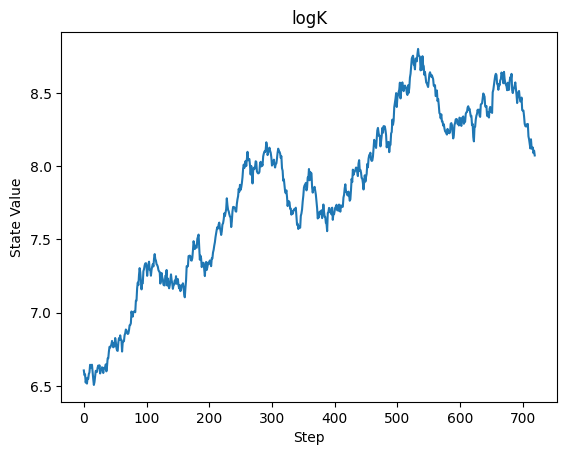

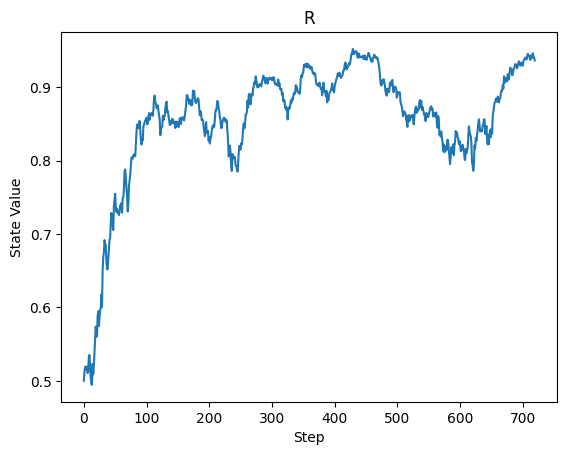

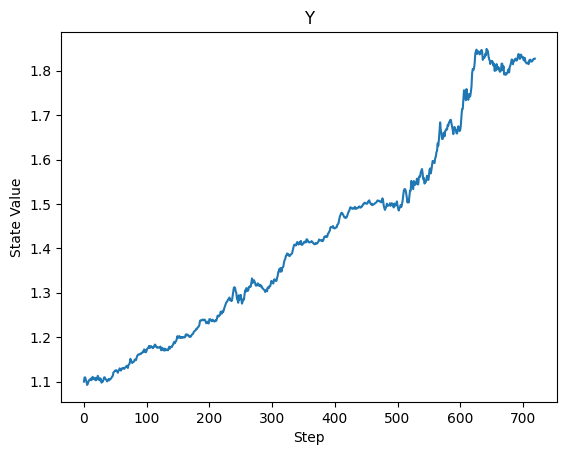

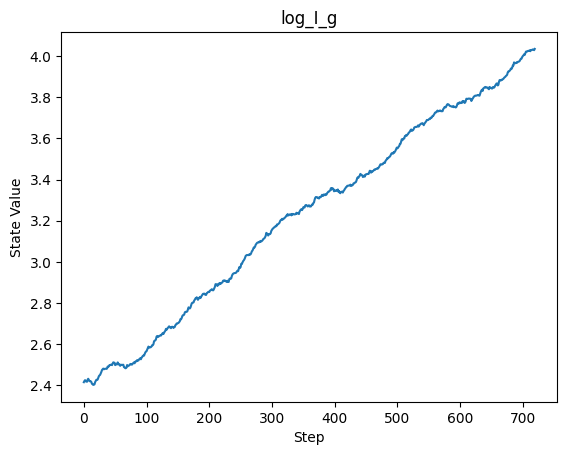

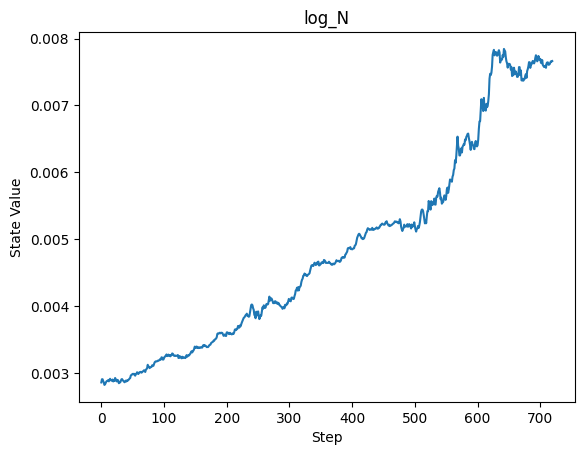

In [141]:
import matplotlib.pyplot as plt

name = ["logK","R","Y","log_I_g","log_N"]
t=-1
for i in [log_K,R,Y,log_I_g,log_N]:
    t+=1
    plt.plot(i)
    plt.xlabel('Step')
    plt.ylabel('State Value')
    plt.title(f'{name[t]}')
    plt.show()

In [142]:

gamma_3_tensor = tf.convert_to_tensor(reloaded_model.params["gamma_3_list"], dtype=tf.float32)

damage_state = []

for k in range(reloaded_model.params["gamma_3_length"]):

    # y_column = tf.fill([state_matrix.shape[0], 1], reloaded_model.params["y_bar"])
    gamma_column = tf.fill([state_matrix.shape[0], 1], gamma_3_tensor[k])

    first_part = state_matrix[:, :4]
    # second_part = state_matrix[:, 3:4]
    third_part = state_matrix[:,4:]
    new_tensor = tf.concat([first_part,gamma_column, third_part], axis=1)
    
    damage_state.append(new_tensor)
    
ag_prime_tensor = tf.convert_to_tensor(reloaded_model.params["A_g_prime_list"], dtype=tf.float32)

tech_state = []

for k in range(reloaded_model.params["A_g_prime_length"]):

    ag_prime_column = tf.fill([state_matrix.shape[0], 1], ag_prime_tensor[k])

    first_part = state_matrix[:, :3]
    second_part = state_matrix[:, 4:6]

    new_tensor = tf.concat([first_part, ag_prime_column, second_part], axis=1)
    
    tech_state.append(new_tensor)
    

In [143]:
dv_damage_list=[]

for k in range(reloaded_model.params["gamma_3_length"]):
    with tf.GradientTape(persistent=True) as tape:  
        tape.watch(damage_state[k])  
        v_pre_tech_post_damage_matrix = reloaded_model.v_pre_tech_post_damage_nn(damage_state[k]) 
   
    dv_pre_tech_post_damage = tape.gradient(v_pre_tech_post_damage_matrix, damage_state[k])
    dv_damage_list.append(dv_pre_tech_post_damage[:,:4])
        
        
        
        
dv_tech_list=[]

for k in range(reloaded_model.params["A_g_prime_length"]):
    with tf.GradientTape(persistent=True) as tape:  
        tape.watch(tech_state[k])  
        v_post_tech_pre_damage_matrix = reloaded_model.v_post_tech_pre_damage_nn(tech_state[k]) 
   
    dv_post_tech_pre_damage = tape.gradient(v_post_tech_pre_damage_matrix,tech_state[k])
    dv_selected_columns = dv_post_tech_pre_damage[:, :3]

    zeros_column = tf.zeros([dv_selected_columns.shape[0], 1], dtype=dv_selected_columns.dtype)

    dv_with_zeros = tf.concat([dv_selected_columns, zeros_column], axis=1)

    dv_tech_list.append(dv_with_zeros)
      
    
del tape

In [144]:
## interpolate derivative

simulate_ss = np.concatenate([state_matrix.numpy()[:,:4], log_N], axis=1)

dmu_log_K = np.array((dmu_logK_dx1_ip(simulate_ss),dmu_logK_dx2_ip(simulate_ss),dmu_logK_dx3_ip(simulate_ss),dmu_logK_dx4_ip(simulate_ss),dmu_logK_dx5_ip(simulate_ss))).T
dmu_R = np.array((dmu_R_dx1_ip(simulate_ss),dmu_R_dx2_ip(simulate_ss),dmu_R_dx3_ip(simulate_ss),dmu_R_dx4_ip(simulate_ss),dmu_R_dx5_ip(simulate_ss))).T
dmu_Y = np.array((dmu_Y_dx1_ip(simulate_ss),dmu_Y_dx2_ip(simulate_ss),dmu_Y_dx3_ip(simulate_ss),dmu_Y_dx4_ip(simulate_ss),dmu_Y_dx5_ip(simulate_ss))).T
dmu_log_I_g = np.array((dmu_log_I_g_dx1_ip(simulate_ss),dmu_log_I_g_dx2_ip(simulate_ss),dmu_log_I_g_dx3_ip(simulate_ss),dmu_log_I_g_dx4_ip(simulate_ss),dmu_log_I_g_dx5_ip(simulate_ss))).T
dmu_logN = np.array((dmu_logN_dx1_ip(simulate_ss),dmu_logN_dx2_ip(simulate_ss),dmu_logN_dx3_ip(simulate_ss),dmu_logN_dx4_ip(simulate_ss),dmu_logN_dx5_ip(simulate_ss))).T

dsigma_log_K =np.array( (dsigma_logK_dx1_ip(simulate_ss),dsigma_logK_dx2_ip(simulate_ss),dsigma_logK_dx3_ip(simulate_ss),dsigma_logK_dx4_ip(simulate_ss),dsigma_logK_dx5_ip(simulate_ss))).T
dsigma_R = np.array((dsigma_R_dx1_ip(simulate_ss),dsigma_R_dx2_ip(simulate_ss),dsigma_R_dx3_ip(simulate_ss),dsigma_R_dx4_ip(simulate_ss),dsigma_R_dx5_ip(simulate_ss))).T
dsigma_Y = np.array((dsigma_Y_dx1_ip(simulate_ss),dsigma_Y_dx2_ip(simulate_ss),dsigma_Y_dx3_ip(simulate_ss),dsigma_Y_dx4_ip(simulate_ss),dsigma_Y_dx5_ip(simulate_ss))).T
dsigma_log_I_g = np.array((dsigma_log_I_g_dx1_ip(simulate_ss),dsigma_log_I_g_dx2_ip(simulate_ss),dsigma_log_I_g_dx3_ip(simulate_ss),dsigma_log_I_g_dx4_ip(simulate_ss),dsigma_log_I_g_dx5_ip(simulate_ss))).T
dsigma_logN = np.array((dsigma_logN_dx1_ip(simulate_ss),dsigma_logN_dx2_ip(simulate_ss),dsigma_logN_dx3_ip(simulate_ss),dsigma_logN_dx4_ip(simulate_ss),dsigma_logN_dx5_ip(simulate_ss))).T

du_array    = np.array((dU_dx1_ip(simulate_ss),dU_dx2_ip(simulate_ss),dU_dx3_ip(simulate_ss),dU_dx4_ip(simulate_ss),dU_dx5_ip(simulate_ss))).T
dJ_tech_array    = np.array((dJ_tech_dx1_ip(simulate_ss),dJ_tech_dx2_ip(simulate_ss),dJ_tech_dx3_ip(simulate_ss),dJ_tech_dx4_ip(simulate_ss),dJ_tech_dx5_ip(simulate_ss))).T
dJ_damage_array    = np.array((dJ_damage_dx1_ip(simulate_ss),dJ_damage_dx2_ip(simulate_ss),dJ_damage_dx3_ip(simulate_ss),dJ_damage_dx4_ip(simulate_ss),dJ_damage_dx5_ip(simulate_ss))).T



In [145]:


m_list=np.zeros((720,5))
m0=np.array((0,0,0,1,0))


m_list[0,:]=m0

for t in range(int(Year/dt)-1):
    
    m_list[t+1,0]= m_list[t,0]+m_list[t,:].reshape(1,5)@dmu_log_K[t,:].reshape(5,1)*dt+m_list[t,:].reshape(1,5)@dsigma_log_K[t,:].reshape(5,1)*dW_d[t]
    m_list[t+1,1]= m_list[t,1]+m_list[t,:].reshape(1,5)@dmu_R[t,:].reshape(5,1)*dt+m_list[t,:].reshape(1,5)@dsigma_R[t,:].reshape(5,1)*dW_g[t]
    m_list[t+1,2]= m_list[t,2]+m_list[t,:].reshape(1,5)@dmu_Y[t,:].reshape(5,1)*dt+m_list[t,:].reshape(1,5)@dsigma_Y[t,:].reshape(5,1)*dW_y[t]
    m_list[t+1,3]= m_list[t,3]+m_list[t,:].reshape(1,5)@dmu_log_I_g[t,:].reshape(5,1)*dt+m_list[t,:].reshape(1,5)@dsigma_log_I_g[t,:].reshape(5,1)*dW_r[t]
    m_list[t+1,4]= m_list[t,4]+m_list[t,:].reshape(1,5)@dmu_logN[t,:].reshape(5,1)*dt+m_list[t,:].reshape(1,5)@dsigma_logN[t,:].reshape(5,1)*dW_y[t]
    

    
    

/home/pengyu/ipykernel_783990/2171099013.py:9: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  m_list[t+1,0]= m_list[t,0]+m_list[t,:].reshape(1,5)@dmu_log_K[t,:].reshape(5,1)*dt+m_list[t,:].reshape(1,5)@dsigma_log_K[t,:].reshape(5,1)*dW_d[t]
/home/pengyu/ipykernel_783990/2171099013.py:10: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  m_list[t+1,1]= m_list[t,1]+m_list[t,:].reshape(1,5)@dmu_R[t,:].reshape(5,1)*dt+m_list[t,:].reshape(1,5)@dsigma_R[t,:].reshape(5,1)*dW_g[t]
/home/pengyu/ipykernel_783990/2171099013.py:11: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extr

In [146]:

r_1         = 1.5
r_2         = 2.5
y_lower_bar = 1.5

J_damage = (r_1 * ( np.exp( r_2 / 2 * np.power( Y - y_lower_bar,2) ) - 1  ) * (Y  > y_lower_bar ))/reloaded_model.params["gamma_3_length"]
J_tech = np.exp(log_I_g)/448/reloaded_model.params["A_g_prime_length"]





In [147]:

dv_damage_values = np.zeros((720, reloaded_model.params["gamma_3_length"]))
dv_tech_values = np.zeros((720, reloaded_model.params["A_g_prime_length"]))

for i in range(reloaded_model.params["gamma_3_length"]):
    dv_damage_values[:, i] = np.sum(m_list[:,:4]*dv_damage_list[i],axis=1)-m_list[:,4]

for i in range(reloaded_model.params["A_g_prime_length"]):
    dv_tech_values[:, i] = np.sum(m_list[:,:4]*dv_tech_list[i],axis=1)-m_list[:,4]
    



In [148]:




# first_term = reloaded_model.params["delta"]*(di_d_log_I_g*(1-R)-di_g_log_I_g*R-di_I_log_I_g)/((reloaded_model.params["A_d"]-i_d_matrix)*(1-R)+(reloaded_model.params["A_g"]-i_g_matrix)*R-i_I_matrix)


first_term = reloaded_model.params['delta']*np.sum(m_list*du_array,axis=1)

second_term = np.sum(m_list*dJ_damage_array,axis=1)*np.sum(f_m_simulation*(v_m_simulation-v_simulation),axis=1)+np.sum(m_list*dJ_tech_array,axis=1)*np.sum(g_j_simulation*(v_j_simulation-v_simulation),axis=1)


third_term= J_damage*np.sum(f_m_simulation*dv_damage_values,axis=1)+ J_tech*np.sum(g_j_simulation*dv_tech_values,axis=1)


forth_term = np.exp(log_xi)*(np.sum(m_list*dJ_damage_array,axis=1)*(np.sum(1-f_m_simulation+f_m_simulation*np.log(f_m_simulation),axis=1))+\
    np.sum(m_list*dJ_tech_array,axis=1)*(np.sum(1-g_j_simulation+g_j_simulation*np.log(g_j_simulation),axis=1)))



discount_dactor = np.exp(-1*np.cumsum(reloaded_model.params['delta']+np.sum(g_j_simulation*J_tech.reshape(-1,1),axis=1)+np.sum(f_m_simulation*J_damage.reshape(-1,1),axis=1))*dt)

first_term_discount=discount_dactor*first_term
second_term_discount=discount_dactor*second_term
third_term_discount=discount_dactor*third_term
forth_term_discount=discount_dactor*forth_term

print("first_term",np.sum(first_term_discount),"second_term",np.sum(second_term_discount),"third_term",np.sum(third_term_discount),"forth_term",np.sum(forth_term_discount))

first_term 0.037507282507619366 second_term 0.126432086959738 third_term 0.01773244667698811 forth_term 0.00020529200582079896


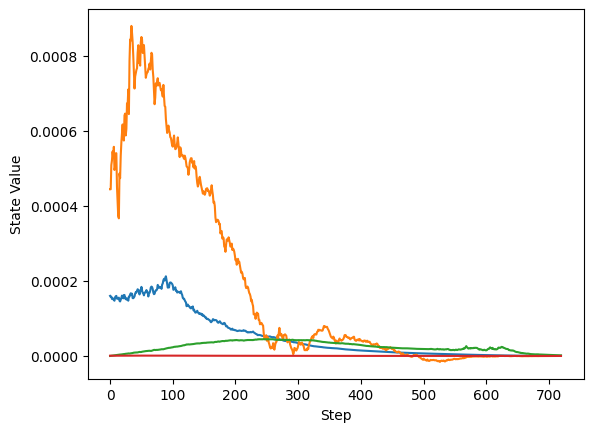

In [149]:
plt.plot(first_term_discount)
plt.plot(second_term_discount)
plt.plot(third_term_discount)
plt.plot(forth_term_discount)

plt.xlabel('Step')
plt.ylabel('State Value')
plt.show()